In [64]:
import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
import cv2
import math

In [2]:
base_dir = Path("images")

images = {}

for subdir in base_dir.iterdir():
    if subdir.is_dir():
        img_dict = {}
        for img_file in subdir.glob("*.[pj][pn]g"):  # matches .png and .jpg
            img_dict[img_file.name] = Image.open(img_file)
        images[subdir.name] = img_dict

print(f"Loaded {sum(len(v) for v in images.values())} images across {len(images)} categories.")

Loaded 10 images across 3 categories.


In [3]:
def print_pics(images_dict, cmap=None):
    if not images_dict:
        print("No images to display.")
        return

    difficulties = sorted(images_dict.keys())

    max_cols = max(len(v) for v in images_dict.values())
    fig, axes = plt.subplots(
        nrows=len(difficulties),
        ncols=max_cols,
        figsize=(3 * max_cols, 3 * len(difficulties))
    )

    if len(difficulties) == 1:
        axes = [axes]
    elif axes.ndim == 1:
        axes = [axes]

    for row_idx, diff in enumerate(difficulties):
        imgs = images_dict[diff]

        sorted_imgs = dict(sorted(imgs.items()))

        for col_idx, (img_name, img) in enumerate(sorted_imgs.items()):
            ax = axes[row_idx][col_idx]
            ax.imshow(img, cmap=cmap)
            ax.set_title(img_name, fontsize=8)
            ax.axis("off")

        for empty_ax in axes[row_idx][len(sorted_imgs):]:
            empty_ax.axis("off")

        axes[row_idx][0].set_ylabel(diff, rotation=0, size='large', labelpad=40, weight='bold')

    plt.tight_layout()
    plt.show()

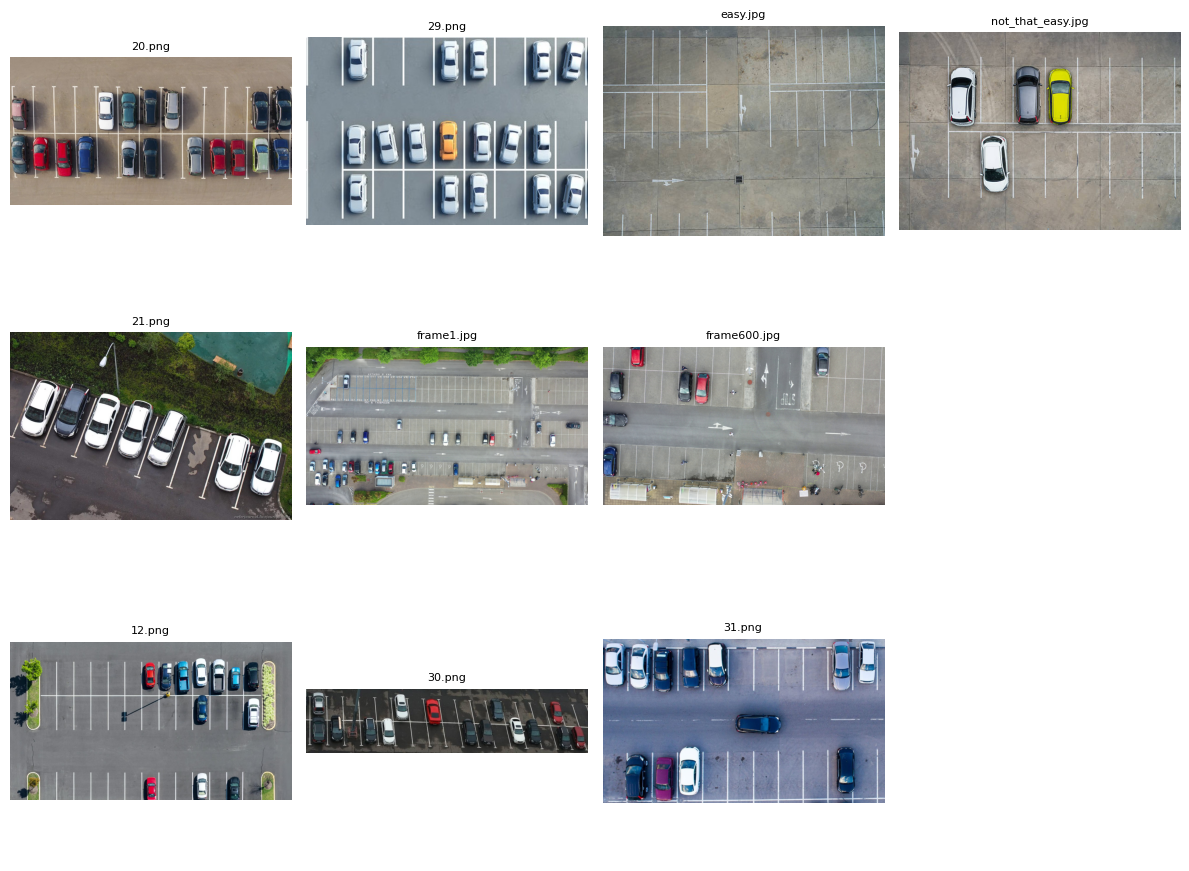

In [4]:
print_pics(images)

In [5]:
# A helper function to apply a transformation to the image array. takes in an input array, an output array, and a function
def apply_technique(input_dict, output_dict, func):
    """
    input_dict : dict
        Nested dict structured as {level: {image_name: image_array}}
    output_dict : dict (empty dict recommended)
        Where transformed results are written using the same nested structure.
    func : function
        Should accept (image, level_index, image_index)
        and return a transformed image.
    """
    output_dict.clear() # clear the output

    # iterate over the the array
    for set_idx, (level, img_set) in enumerate(input_dict.items()):
        new_level = {}

        for img_idx, (img_name, img) in enumerate(img_set.items()):
            new_level[img_name] = func(img, set_idx, img_idx)

        output_dict[level] = new_level

    return output_dict

In [6]:
def print_image_shapes(images_dict):
    """
    Print the shape and dtype of every image in the nested dictionary.
    """
    for level, img_set in images_dict.items():
        print(f"\n=== Level: {level} ===")
        for img_name, img in img_set.items():
            
            # Convert PIL → NumPy for shape/dtype
            if isinstance(img, Image.Image):
                arr = np.array(img)
            else:
                arr = img

            print(f"{img_name:<20}  shape={arr.shape}  dtype={arr.dtype}")


print_image_shapes(images)


=== Level: easy ===
easy.jpg              shape=(459, 612, 3)  dtype=uint8
29.png                shape=(318, 477, 3)  dtype=uint8
20.png                shape=(630, 1200, 3)  dtype=uint8
not_that_easy.jpg     shape=(433, 612, 3)  dtype=uint8

=== Level: medium ===
12.png                shape=(1080, 1920, 3)  dtype=uint8
31.png                shape=(827, 1412, 3)  dtype=uint8
30.png                shape=(204, 890, 3)  dtype=uint8

=== Level: hard ===
frame600.jpg          shape=(2160, 3840, 3)  dtype=uint8
21.png                shape=(733, 1100, 3)  dtype=uint8
frame1.jpg            shape=(2160, 3840, 3)  dtype=uint8


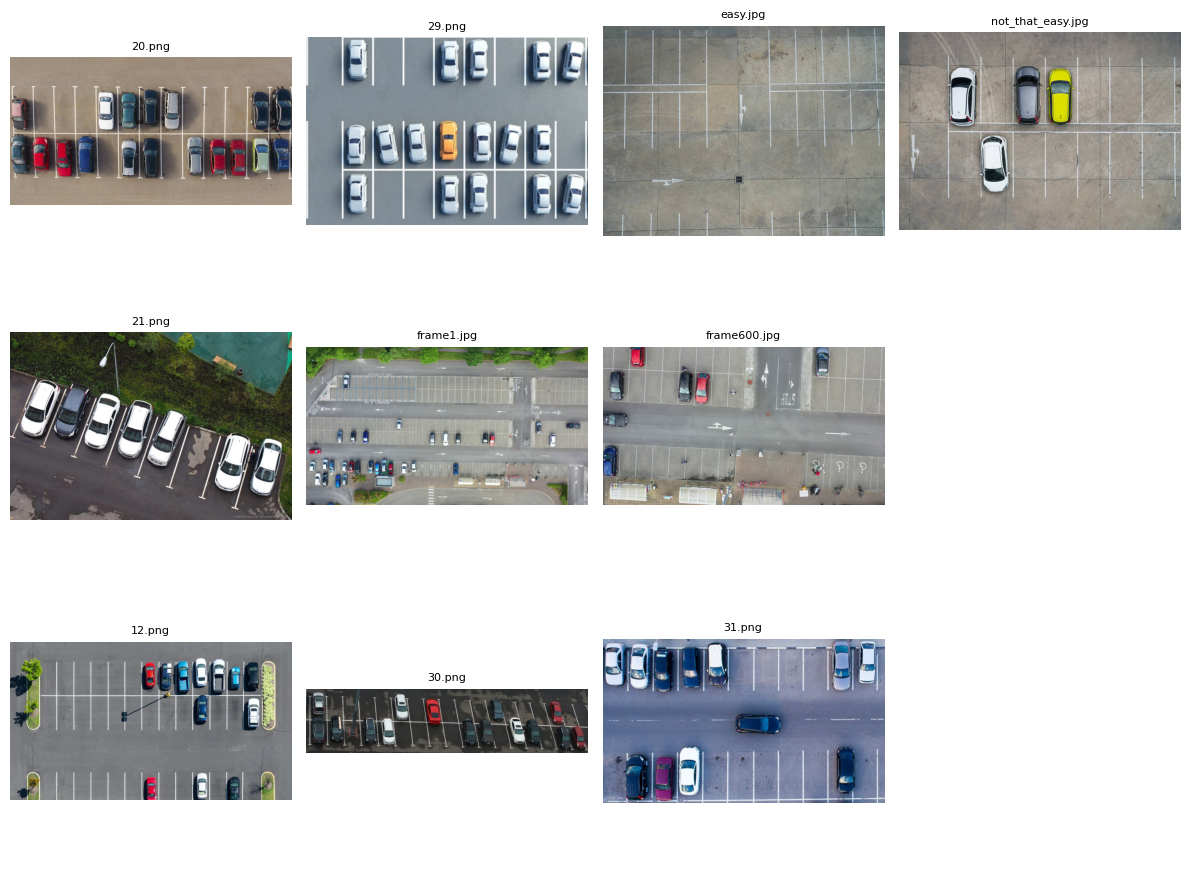

In [8]:
def resize_long_side(img, set_idx, img_idx, long_side=1024):
    """
    Resize image so its longest side = long_side.
    Returns ONLY the resized NumPy image (same structure as original code expects).
    """
    # convert PIL -> numpy if needed
    if isinstance(img, Image.Image):
        arr = np.array(img)
    else:
        arr = img

    h, w = arr.shape[:2]
    scale = long_side / max(h, w)

    new_w = int(w * scale)
    new_h = int(h * scale)

    proc = cv2.resize(arr, (new_w, new_h), interpolation=cv2.INTER_AREA)

    return proc

resized_images = {}
apply_technique(images, resized_images, resize_long_side)
print_pics(resized_images)

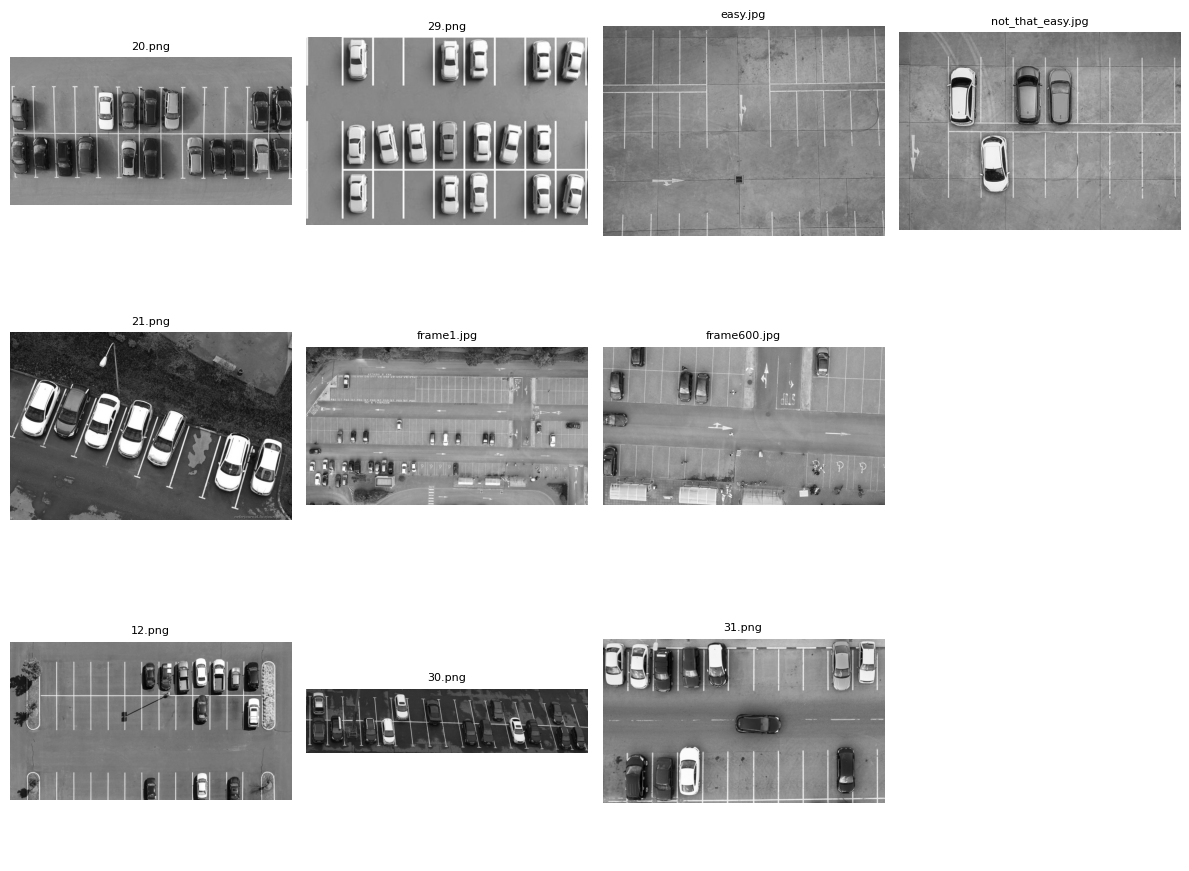

In [16]:
def to_greyscale(img, set_idx, img_idx):

    arr = np.array(img)

    # If already grayscale (H,W), return as-is
    if arr.ndim == 2:
        return arr
    grey = cv2.cvtColor(arr, cv2.COLOR_BGR2GRAY)

    return grey

grey_images = {}
apply_technique(resized_images, grey_images, to_greyscale)
print_pics(grey_images, cmap="gray")

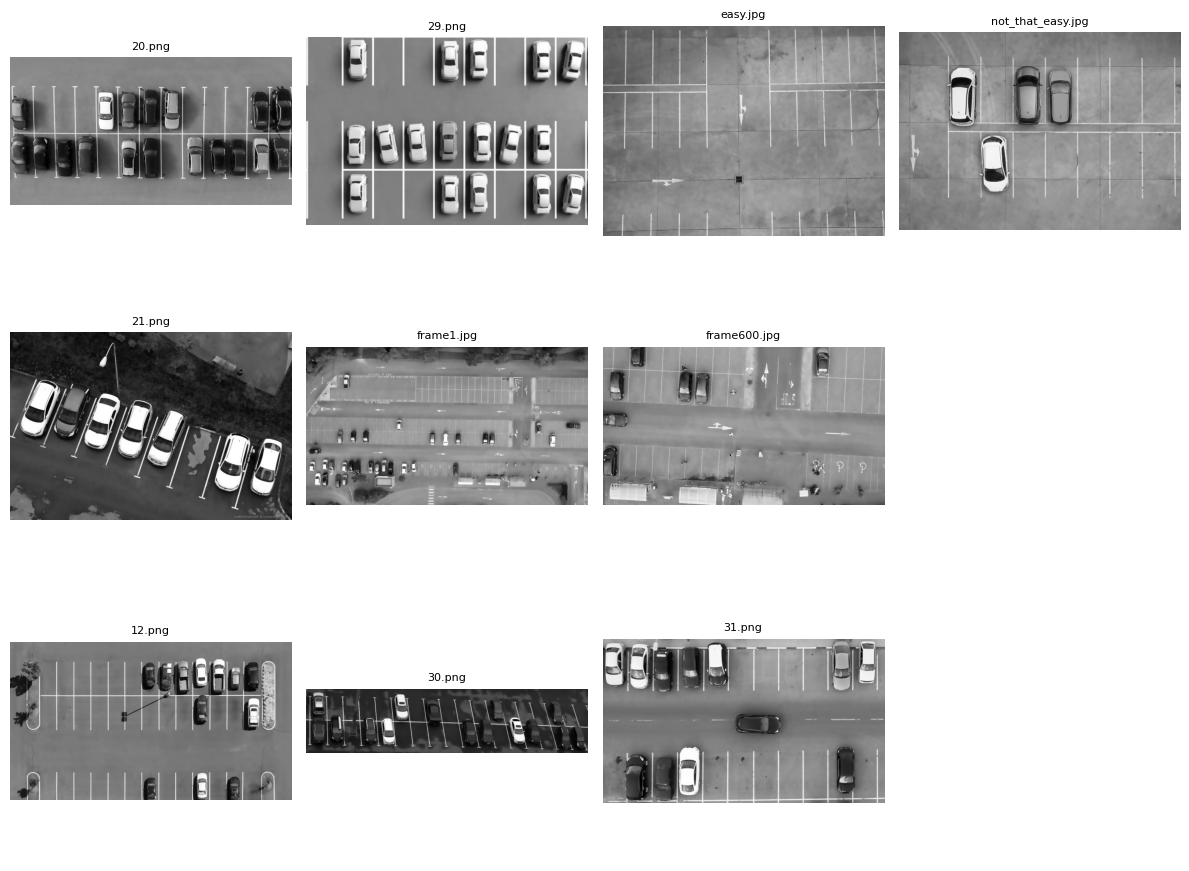

In [25]:
def bilateral_filter(img, set_idx, img_idx):
    """Denoise while preserving edges (best for faint lines)."""
    h, w = img.shape[:2]
    kernel_size = int(max(h, w) * 0.02)
    return cv2.bilateralFilter(img, 12, kernel_size, kernel_size)

bilateral_images = {}
apply_technique(grey_images, bilateral_images, bilateral_filter)
print_pics(bilateral_images, cmap="gray")

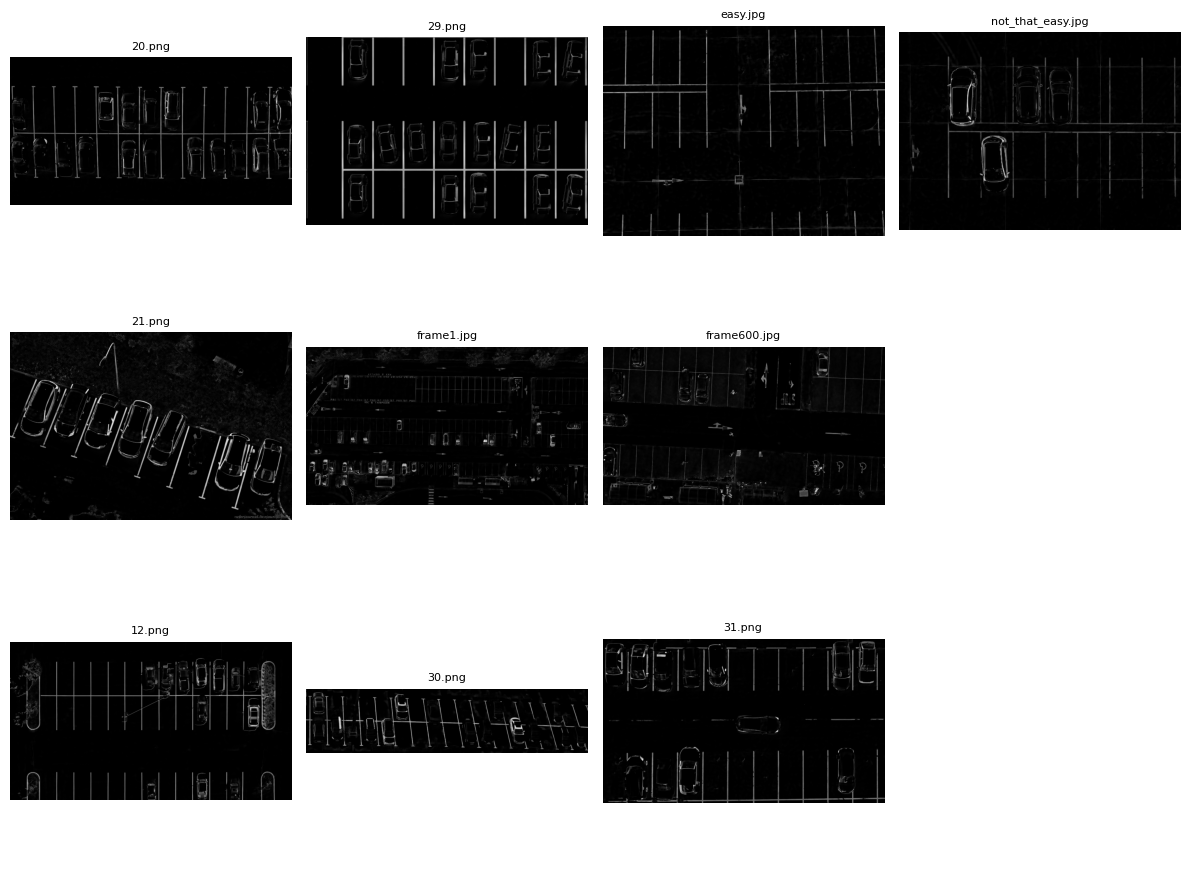

In [39]:
def white_top_hat(img, set_idx, img_idx):
    """Enhance bright thin features (parking lines)."""
    # Kernel size affects thickness of extracted lines; 25–35 is typical
    arr = np.array(img)
    h, w = arr.shape[:2]
    kernel_size = int(max(h, w) * 0.01)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_size, kernel_size))
    tophat = cv2.morphologyEx(img, cv2.MORPH_TOPHAT, kernel)
    return tophat

enhanced = {}
apply_technique(bilateral_images, enhanced, white_top_hat)
print_pics(enhanced, cmap="gray")

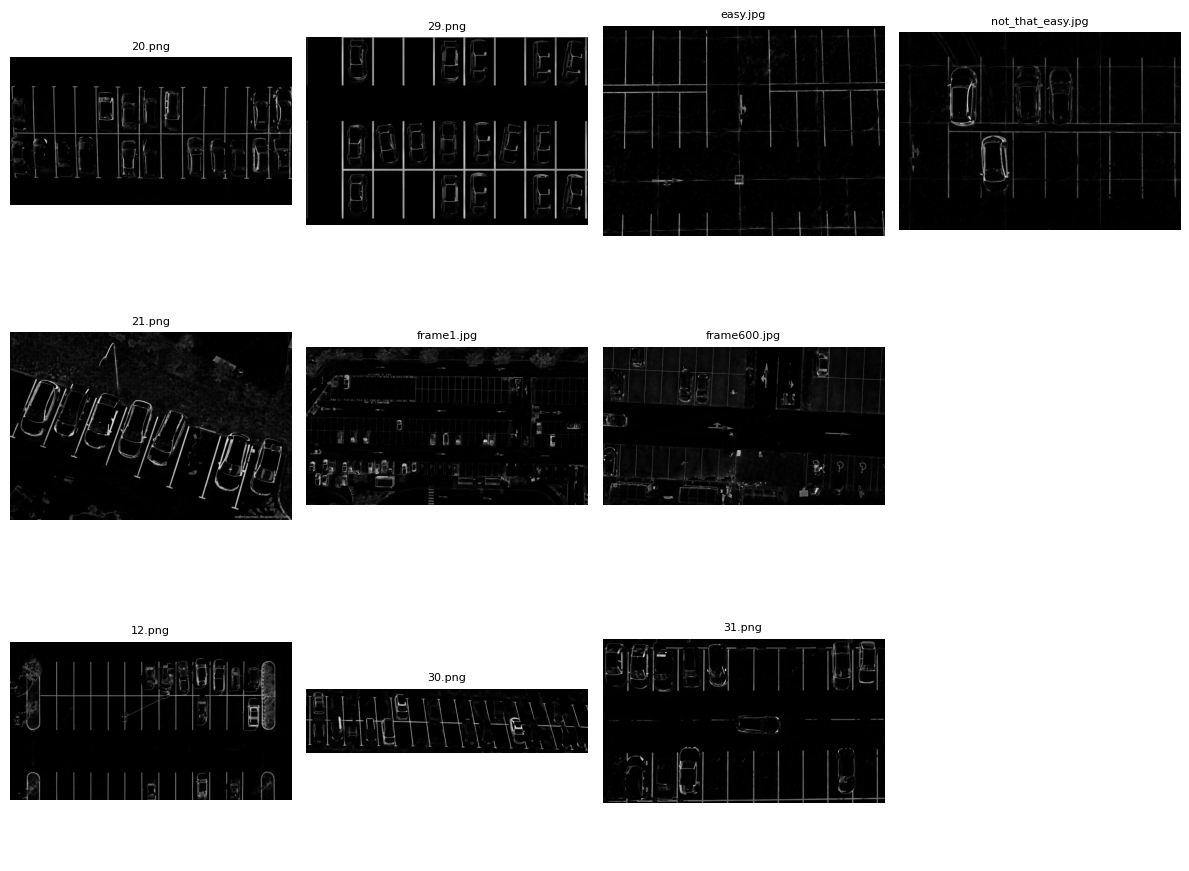

In [40]:
def morphology_close(img, set_idx, img_idx):
    """Close gaps in broken line segments (very important)."""
    arr = np.array(img)
    h, w = arr.shape[:2]
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    closed = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)
    return closed

first_closed = {}
apply_technique(enhanced, first_closed, morphology_close)
print_pics(first_closed, cmap="gray")

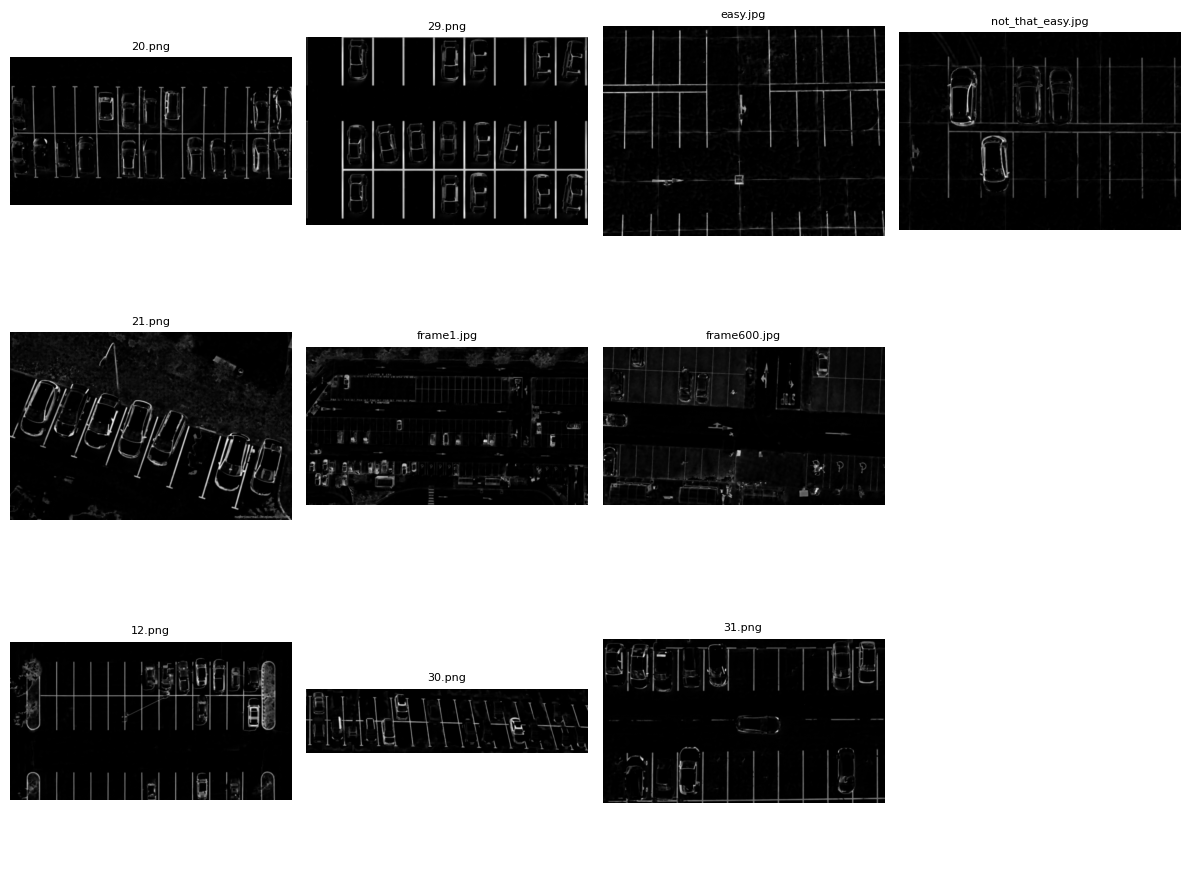

In [44]:
def post_close_blur(img, set_idx, img_idx):
    """
    Apply a light Gaussian blur after morphological close.
    This suppresses asphalt noise while keeping parking lines intact.
    """
    # Convert PIL to numpy if needed
    if isinstance(img, Image.Image):
        arr = np.array(img)
    else:
        arr = img

    # Apply a small blur to kill high-frequency noise
    blurred = cv2.GaussianBlur(arr, (5, 5), sigmaX=1.0, sigmaY=1.0)

    return blurred

blurred_after_close = {}
apply_technique(first_closed, blurred_after_close, post_close_blur)
print_pics(blurred_after_close, cmap="gray")

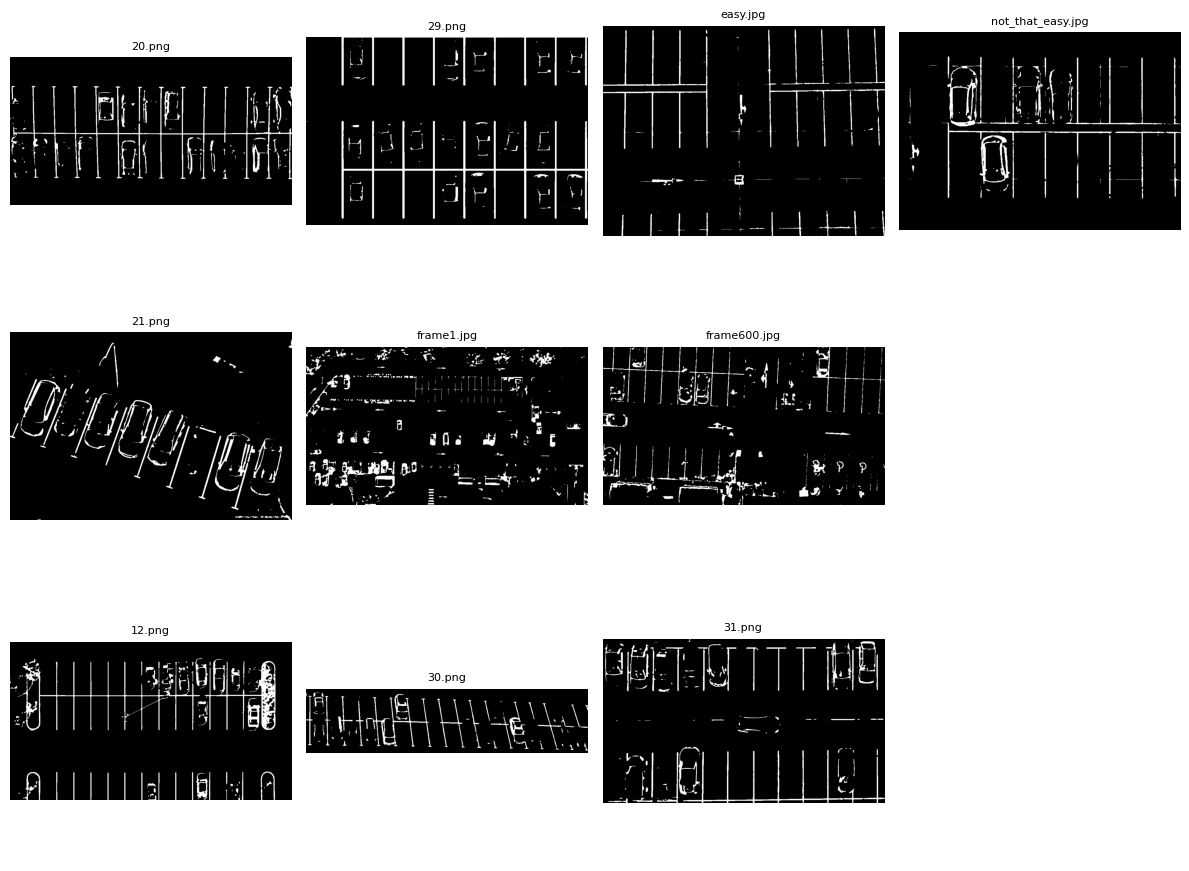

In [46]:
def binarise_otsu(img, set_idx, img_idx):
    """
    Binarize using Otsu's method after blur.
    Works extremely well on post-close, post-blur images.
    """
    if isinstance(img, Image.Image):
        arr = np.array(img)
    else:
        arr = img

    # If it's RGB, reduce to grayscale
    if arr.ndim == 3:
        arr = cv2.cvtColor(arr, cv2.COLOR_BGR2GRAY)

    # Otsu thresholding
    _, binary = cv2.threshold(arr, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    return binary

binarised = {}
apply_technique(blurred_after_close, binarised, binarise_otsu)
print_pics(binarised, cmap="gray")

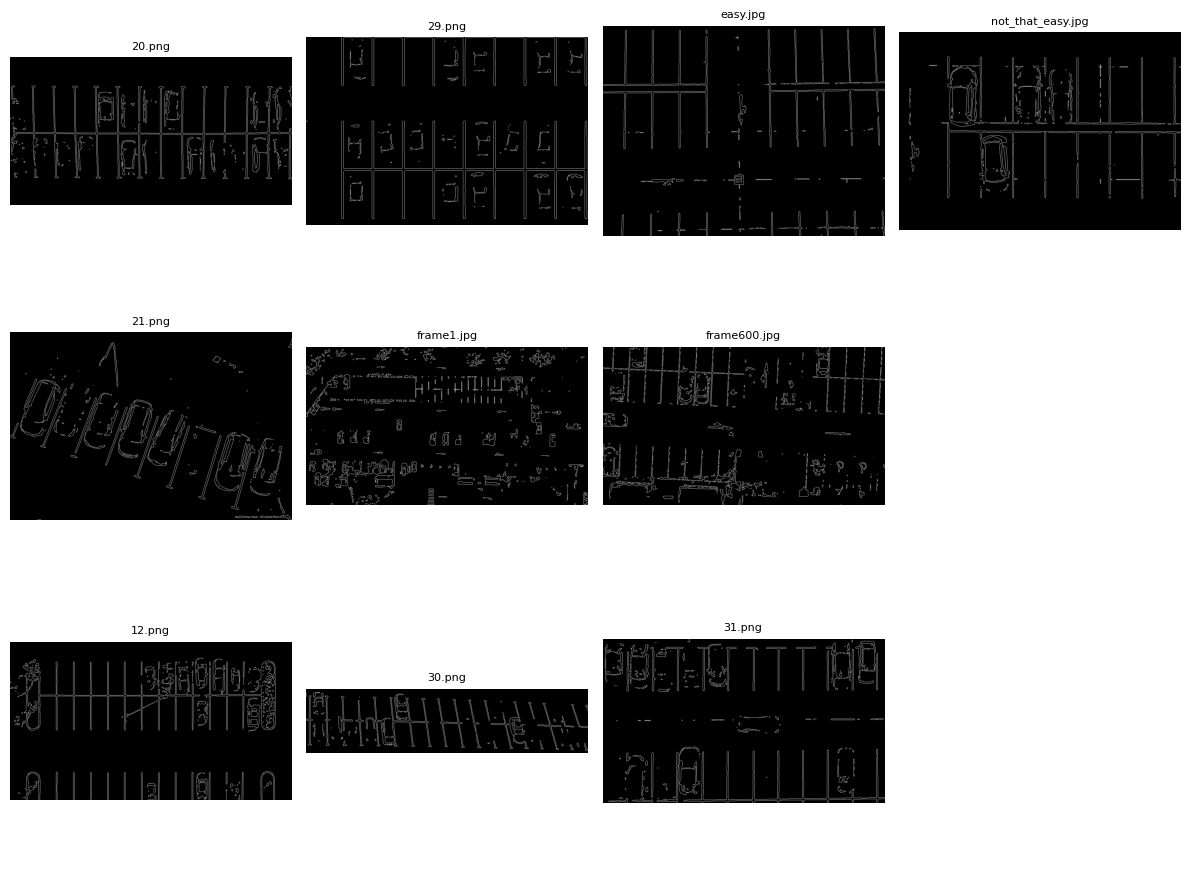

In [48]:
def adaptive_canny(img, set_idx, img_idx, sigma=0.33):
    """Adaptive Canny thresholds based on image statistics."""
    med = np.median(img)
    
    low  = int(max(0,  (1.0 - sigma) * med))
    high = int(min(255, (1.0 + sigma) * med))

    blurred = cv2.GaussianBlur(img, (15,15), 1.0)
    edges = cv2.Canny(img, low, high)
    return edges

edges = {}
apply_technique(binarised, edges, adaptive_canny)
print_pics(edges, cmap="gray")

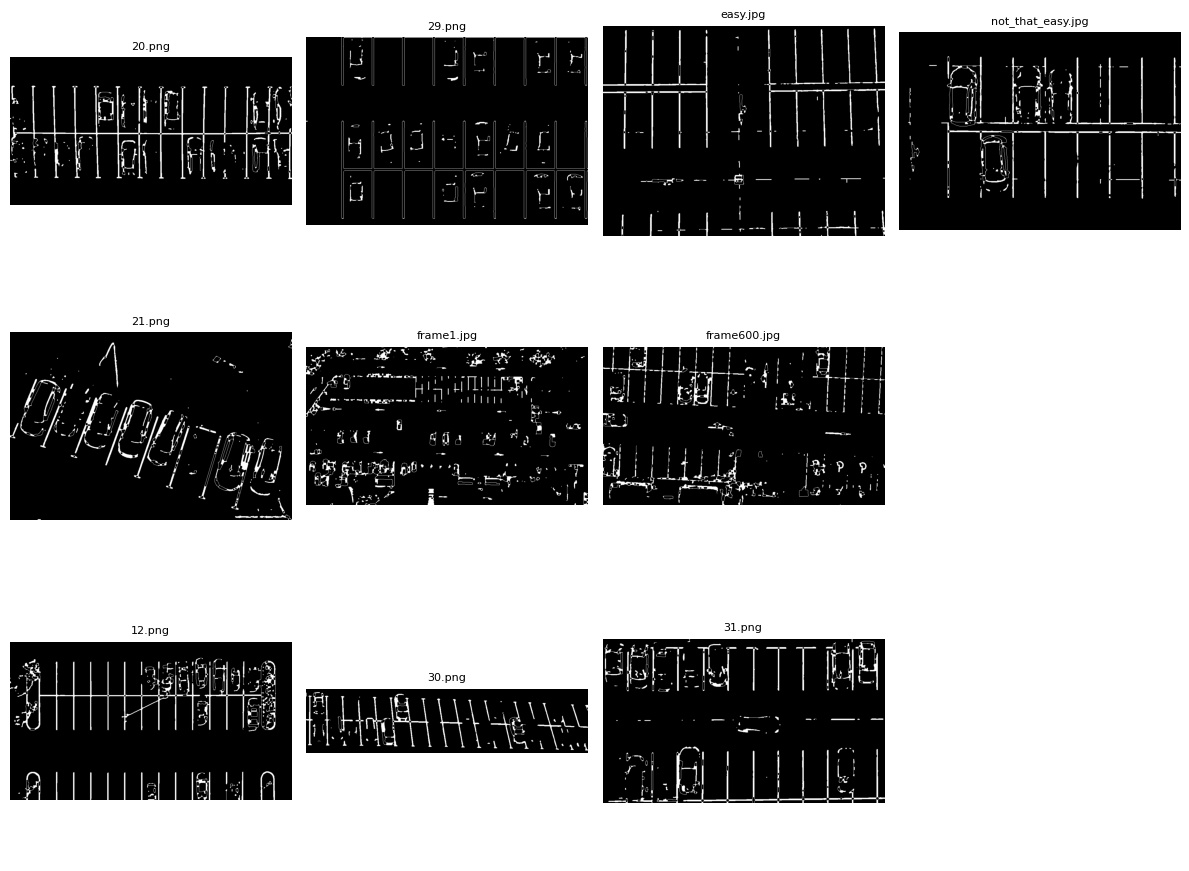

In [51]:
def morphology_close(img, set_idx, img_idx):
    """Close gaps in broken line segments (very important)."""
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    closed = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)
    return closed

closed = {}
apply_technique(edges, closed, morphology_close)
print_pics(closed, cmap="gray")

In [60]:
def hough_lines_p(edges, set_idx, img_idx):
    """Run Probabilistic Hough Transform on the processed edges."""
    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi/180,
        threshold=60,
        minLineLength=70,   # You may tune this after inspecting images
        maxLineGap=10
    )
    return lines

lines = {}
apply_technique(closed, lines, hough_lines_p)
# print_pics(lines, cmap="gray")

{'easy': {'easy.jpg': array([[[ 604,  116,  610,  444]],
  
         [[ 603,  240,  917,  234]],
  
         [[ 376,  446,  376,   18]],
  
         [[ 890,   14,  896,  212]],
  
         [[ 791,   17,  798,  213]],
  
         [[ 699,   16,  702,  215]],
  
         [[  53,  215,  378,  215]],
  
         [[ 911,  236, 1023,  234]],
  
         [[ 277,  767,  277,  685]],
  
         [[ 279,  145,  279,   18]],
  
         [[ 172,  767,  173,  688]],
  
         [[ 706,  313,  708,  442]],
  
         [[  80,  449,   80,  325]],
  
         [[  80,  220,   84,   19]],
  
         [[ 602,  116,  608,  444]],
  
         [[ 988,  115,  993,  211]],
  
         [[ 278,  145,  278,   19]],
  
         [[  78,  220,   81,   20]],
  
         [[ 611,  683,  612,  767]],
  
         [[ 178,  449,  178,  255]],
  
         [[ 374,  401,  374,   42]],
  
         [[ 377,  446,  377,   18]],
  
         [[   0,  243,  378,  243]],
  
         [[ 155,  241,  378,  241]],
  
         [[ 180,  22

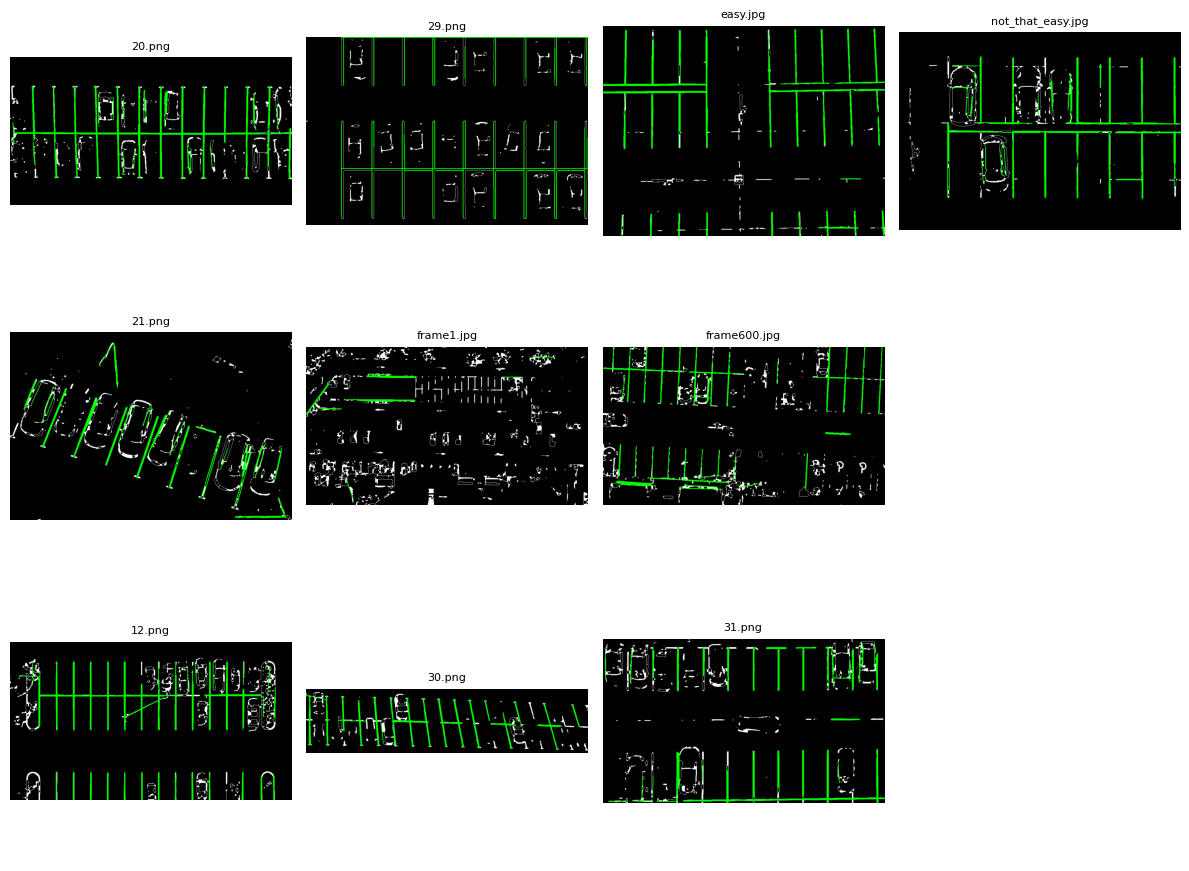

In [61]:
def draw_hough_lines(img, set_idx, img_idx):
    """
    Draw Hough lines stored in global 'lines' using set_idx/img_idx indexing.
    """


    base = np.array(img)


    # ensure BGR for drawing
    if base.ndim == 2:
        vis = cv2.cvtColor(base, cv2.COLOR_GRAY2BGR)
    else:
        vis = base.copy()

    # --- get the matching level name and image name from global 'lines' ---
    level = list(lines.keys())[set_idx]
    img_name = list(lines[level].keys())[img_idx]

    line_set = lines[level][img_name]

    # no lines → return unchanged
    if line_set is None:
        return vis

    # draw each line segment
    for ln in line_set:
        x1, y1, x2, y2 = ln[0]
        cv2.line(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)

    return vis

drawn = {}
apply_technique(closed, drawn, draw_hough_lines)
print_pics(drawn)

In [65]:
def classify_lines_step(img, set_idx, img_idx):
    """
    Classify Hough lines for this specific image into vertical and horizontal.
    Compatible with apply_technique.
    """

    # figure out which image this is using ordering
    level = list(lines.keys())[set_idx]
    img_name = list(lines[level].keys())[img_idx]

    line_set = lines[level][img_name]

    # If no lines, return empty sets
    if line_set is None:
        return {"vertical": [], "horizontal": []}

    vertical = []
    horizontal = []

    for ln in line_set:
        x1, y1, x2, y2 = ln[0]
        angle = abs(math.degrees(math.atan2(y2 - y1, x2 - x1)))

        if angle > 45:   # vertical-ish
            vertical.append((x1, y1, x2, y2))
        else:            # horizontal-ish
            horizontal.append((x1, y1, x2, y2))

    return {
        "vertical": vertical,
        "horizontal": horizontal
    }

classified = {}
apply_technique(closed, classified, classify_lines_step)


{'easy': {'easy.jpg': {'vertical': [(np.int32(604),
     np.int32(116),
     np.int32(610),
     np.int32(444)),
    (np.int32(376), np.int32(446), np.int32(376), np.int32(18)),
    (np.int32(890), np.int32(14), np.int32(896), np.int32(212)),
    (np.int32(791), np.int32(17), np.int32(798), np.int32(213)),
    (np.int32(699), np.int32(16), np.int32(702), np.int32(215)),
    (np.int32(277), np.int32(767), np.int32(277), np.int32(685)),
    (np.int32(279), np.int32(145), np.int32(279), np.int32(18)),
    (np.int32(172), np.int32(767), np.int32(173), np.int32(688)),
    (np.int32(706), np.int32(313), np.int32(708), np.int32(442)),
    (np.int32(80), np.int32(449), np.int32(80), np.int32(325)),
    (np.int32(80), np.int32(220), np.int32(84), np.int32(19)),
    (np.int32(602), np.int32(116), np.int32(608), np.int32(444)),
    (np.int32(988), np.int32(115), np.int32(993), np.int32(211)),
    (np.int32(278), np.int32(145), np.int32(278), np.int32(19)),
    (np.int32(78), np.int32(220), np.int

In [66]:
def merge_lines_step(classified_dict):
    """
    Returns an apply_technique function that merges vertical + horizontal lines
    for each image using their classified lines.
    """

    def merge_for_one(img, set_idx, img_idx):
        # Determine which image this is
        level = list(classified_dict.keys())[set_idx]
        img_name = list(classified_dict[level].keys())[img_idx]

        groups = classified_dict[level][img_name]
        vlines = groups["vertical"]
        hlines = groups["horizontal"]

        def merge_group(lines, dist_thresh=20):
            """
            Merge parallel lines by grouping lines with similar distance
            to origin in Hesse normal form.
            """
            if len(lines) == 0:
                return []

            # Convert to Hesse normal form
            hesse = []
            for (x1, y1, x2, y2) in lines:
                theta = math.atan2(y2 - y1, x2 - x1)
                r = x1 * math.cos(theta) + y1 * math.sin(theta)
                hesse.append((r, theta, (x1, y1, x2, y2)))

            # Sort by r
            hesse.sort(key=lambda x: x[0])

            clusters = []
            cur = [hesse[0]]

            for h in hesse[1:]:
                if abs(h[0] - cur[-1][0]) < dist_thresh:
                    cur.append(h)
                else:
                    clusters.append(cur)
                    cur = [h]

            clusters.append(cur)

            merged = []
            for cl in clusters:
                pts = []
                for _, _, (x1, y1, x2, y2) in cl:
                    pts.append((x1, y1))
                    pts.append((x2, y2))
                xs = [p[0] for p in pts]
                ys = [p[1] for p in pts]
                merged.append((min(xs), min(ys), max(xs), max(ys)))
            return merged

        return {
            "vmerged": merge_group(vlines),
            "hmerged": merge_group(hlines)
        }

    return merge_for_one

merged = {}
apply_technique(classified, merged, merge_lines_step(classified))

{'easy': {'easy.jpg': {'vmerged': [(np.int32(66),
     np.int32(682),
     np.int32(379),
     np.int32(767)),
    (np.int32(75), np.int32(18), np.int32(377), np.int32(450)),
    (np.int32(75), np.int32(42), np.int32(379), np.int32(418)),
    (np.int32(76), np.int32(237), np.int32(705), np.int32(346)),
    (np.int32(78), np.int32(18), np.int32(281), np.int32(220)),
    (np.int32(183), np.int32(18), np.int32(378), np.int32(154)),
    (np.int32(599), np.int32(12), np.int32(996), np.int32(215)),
    (np.int32(177), np.int32(111), np.int32(701), np.int32(444)),
    (np.int32(988), np.int32(115), np.int32(993), np.int32(211)),
    (np.int32(603), np.int32(213), np.int32(607), np.int32(444)),
    (np.int32(180), np.int32(233), np.int32(1004), np.int32(442)),
    (np.int32(376), np.int32(676), np.int32(1018), np.int32(767)),
    (np.int32(1016), np.int32(676), np.int32(1022), np.int32(762))],
   'hmerged': [(np.int32(0), np.int32(216), np.int32(378), np.int32(247)),
    (np.int32(50), np.int3

In [67]:
def intersections_step(merged_dict):
    """
    Returns apply_technique-compatible function that computes
    intersections for each image.
    """

    def intersect_one(img, set_idx, img_idx):
        level = list(merged_dict.keys())[set_idx]
        img_name = list(merged_dict[level].keys())[img_idx]

        groups = merged_dict[level][img_name]
        vlines = groups["vmerged"]
        hlines = groups["hmerged"]

        def intersect(l1, l2):
            x1, y1, x2, y2 = l1
            x3, y3, x4, y4 = l2

            denom = (x1-x2)*(y3-y4) - (y1-y2)*(x3-x4)
            if denom == 0:
                return None

            px = ((x1*y2 - y1*x2)*(x3-x4) - (x1-x2)*(x3*y4 - y3*x4)) / denom
            py = ((x1*y2 - y1*x2)*(y3-y4) - (y1-y2)*(x3*y4 - y3*x4)) / denom

            return (px, py)

        pts = []

        for v in vlines:
            for h in hlines:
                p = intersect(v, h)
                if p is not None:
                    pts.append(p)

        return {"points": pts}

    return intersect_one

intersections = {}
apply_technique(merged, intersections, intersections_step(merged))

{'easy': {'easy.jpg': {'points': [(np.float64(-2363.8357337138273),
     np.float64(22.140455700717883)),
    (np.float64(-2394.6964846363685), np.float64(13.759740593957487)),
    (np.float64(-1557.9176470588236), np.float64(241.0)),
    (np.float64(-1657.3411764705882), np.float64(214.0)),
    (np.float64(-1841.7227411720353), np.float64(163.92832907468687)),
    (np.float64(-1823.3180942871406), np.float64(168.92639612010555)),
    (np.float64(-1923.4868015083991), np.float64(141.72403153925265)),
    (np.float64(230.86184002529245), np.float64(726.7707872273159)),
    (np.float64(233.3212868184667), np.float64(727.4386881136411)),
    (np.float64(1250.4889699697173), np.float64(1003.6663336978465)),
    (np.float64(-12981.141885325558), np.float64(-2861.153547133139)),
    (np.float64(226.39629971286396), np.float64(234.56689230449413)),
    (np.float64(222.65303799553698), np.float64(229.21229276182774)),
    (np.float64(230.8935185185185), np.float64(241.0)),
    (np.float64(212.

In [68]:
def grid_step(intersections_dict, row_thresh=20):
    """
    Returns apply_technique-compatible function to sort intersections
    into a row/column grid.
    """

    def grid_one(img, set_idx, img_idx):
        level = list(intersections_dict.keys())[set_idx]
        img_name = list(intersections_dict[level].keys())[img_idx]

        pts = intersections_dict[level][img_name]["points"]

        if len(pts) == 0:
            return {"rows": []}

        # sort by y then x
        pts_sorted = sorted(pts, key=lambda p: (p[1], p[0]))

        # cluster rows
        rows = []
        cur = [pts_sorted[0]]

        for p in pts_sorted[1:]:
            if abs(p[1] - cur[-1][1]) < row_thresh:
                cur.append(p)
            else:
                rows.append(cur)
                cur = [p]
        rows.append(cur)

        # sort each row by x
        rows = [sorted(r, key=lambda p: p[0]) for r in rows]

        return {"rows": rows}

    return grid_one

grid = {}
apply_technique(intersections, grid, grid_step(intersections))

{'easy': {'easy.jpg': {'rows': [[(np.float64(-12981.141885325558),
      np.float64(-2861.153547133139))],
    [(np.float64(-5417.664082687338), np.float64(-1186.795865633075))],
    [(np.float64(-6929.789675563369), np.float64(-359.5558574396676)),
     (np.float64(-6808.58940397351), np.float64(-342.37637969094925))],
    [(np.float64(594.5390975024134), np.float64(-275.61711923562467))],
    [(np.float64(-2394.6964846363685), np.float64(13.759740593957487)),
     (np.float64(-2363.8357337138273), np.float64(22.140455700717883)),
     (np.float64(33.8479262672811), np.float64(20.027403524817956)),
     (np.float64(62.333333333333336), np.float64(26.333333333333332)),
     (np.float64(84.211397750554), np.float64(31.17656896767989)),
     (np.float64(93.25336573511544), np.float64(33.17822600243014))],
    [(np.float64(256.6160677575857), np.float64(69.34248828221364))],
    [(np.float64(-3728.377130681818), np.float64(94.22691761363636)),
     (np.float64(-3590.200298297947), np.floa

In [69]:
def slots_step(grid_dict):
    """
    Returns apply_technique-compatible function to build
    parking-stall polygons from the intersection grid.
    """

    def slots_one(img, set_idx, img_idx):
        level = list(grid_dict.keys())[set_idx]
        img_name = list(grid_dict[level].keys())[img_idx]

        rows = grid_dict[level][img_name]["rows"]

        slots = []
        for r in range(len(rows)-1):
            row1 = rows[r]
            row2 = rows[r+1]

            if len(row1) != len(row2):
                continue    # skip malformed rows

            for c in range(len(row1)-1):
                p1 = row1[c]
                p2 = row1[c+1]
                p3 = row2[c+1]
                p4 = row2[c]

                slots.append([p1, p2, p3, p4])

        return {"slots": slots}

    return slots_one

slots = {}
apply_technique(grid, slots, slots_step(grid))

{'easy': {'easy.jpg': {'slots': []},
  '29.png': {'slots': []},
  '20.png': {'slots': []},
  'not_that_easy.jpg': {'slots': []}},
 'medium': {'12.png': {'slots': []},
  '31.png': {'slots': []},
  '30.png': {'slots': []}},
 'hard': {'frame600.jpg': {'slots': []},
  '21.png': {'slots': []},
  'frame1.jpg': {'slots': [[(np.float64(43.10526315789474), np.float64(194.0)),
     (np.float64(48.983193277310924), np.float64(194.0)),
     (np.float64(72.38828967642527), np.float64(226.01386748844376)),
     (np.float64(54.248453117563066), np.float64(225.3660161827701))]]}}}